<br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150> <br>
<font color=0F5298 size=7>
    Machine learning <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Fall 2025<br>
<font color=3C99D size=5>
    Practical Assignment 5 - NLP - Word Embeddings & Fine-Tuning <br>
</div>
<div dir=ltr align=center>
<font color=0CBCDF size=4>
     Emad Rostamian, Seyed Moein Ayyoubzadeh
<br>
<font color=0CBCDF size=4>
</div>

____

<font color=9999FF size=4>
Full Name : Mobina Poulaei
<br>
<font color=9999FF size=4>
Student Number : 403206962

<font color=0080FF size=3>
This notebook covers two related topics in modern NLP. In the first part, we study word embedding methods, including traditional and neural approaches, to understand how semantic information is represented in vector space. In the second part, we explore fine-tuning strategies for pretrained language models, with a focus on parameter-efficient methods such as LoRA, and analyze their behavior during training.
</font>

# Section 1: Exploring Word Embeddings

## 🎯 Objective

In this section, you will **build, explore, and compare different types of word representations (embeddings)** to understand how machines capture the meaning of words from text.


---

## 📚 Dataset

We will work with the complete **_Harry Potter_ series (Books 1–7)**, loaded from a public Hugging Face dataset.

⚠️ **Note:** This text is used **only for educational purposes**.


---

## 🛠️ What You Will Do

You will:
1. **Implement from scratch**
   - TF-IDF
   - Word2Vec-style embeddings (CBOW and Skip-Gram)
   - Nearest-neighbor search (word similarity)
2. **GloVe: Global Vectors for Word Representation**
   - Exploring word vectors
   - Word Analogies

## Part 1: Implement from scratch

## 1. Traditional Word Representations: TF-IDF

Before learning dense vector embeddings, we start with a **traditional and interpretable** way of representing words: **TF-IDF**.

TF-IDF does *not* try to learn meaning from prediction tasks. Instead, it represents words based on how **frequently** they appear and how **informative** they are across documents.

---

## Term Frequency (TF)

Term Frequency measures how often a word appears in a document.

For a word $ w $ in document $ d $:

$$
\text{TF}(w, d) = \frac{\text{count of } w \text{ in } d}{\text{total number of words in } d}
$$

Intuition:
- Words that appear often in a document are likely important *for that document*

---

## Inverse Document Frequency (IDF)

Inverse Document Frequency downweights words that appear in *many* documents.

$$
\text{IDF}(w) = \log\left(\frac{1 + N}{1 + \text{DF}(w)}\right) + 1
$$

Where:
- $ N $ = total number of documents  
- $ \text{DF}(w) $ = number of documents containing word \( w \)

Why the **+1** terms:
- `+1` in the denominator prevents division by zero  
- `+1` in the numerator keeps the ratio ≥ 1  
- `+1` outside the log prevents zero IDF values  

Intuition:
- Common words get low weight  
- Rare words get high weight  
- All words keep a positive contribution  


---

## TF-IDF Score

The final TF-IDF representation combines both ideas:

$$
\text{TF-IDF}(w, d) = \text{TF}(w, d) \times \text{IDF}(w)
$$

Each document is represented as a **high-dimensional sparse vector**, where:
- Each dimension corresponds to a word in the vocabulary
- Values reflect word importance


---

## Your Task

In this section, you will:

1. Load **Harry Potter and the Sorcerer’s Stone**
2. Split the book into **chapters** (each chapter = one document)
3. Build **TF-IDF vectors from scratch**
4. Use TF-IDF to:
   - Find the most important words in a chapter
   - Compute similarity between chapters
   - Compare words based on their TF-IDF representations

Do **not** use `sklearn`’s `TfidfVectorizer`.

The goal is to understand *how TF-IDF works internally*.


In [ ]:
# Standard library
import re
import math
import random
from collections import Counter, defaultdict

# Third-party libraries
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Hugging Face
from datasets import load_dataset

# Scikit-learn
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [ ]:
# Load dataset
hp_ds = load_dataset("elricwan/HarryPotter")

# Each book is one document
books = hp_ds["train"]

# Extract book texts
documents = [book["content"] for book in books]
documents = documents[:-1]
print(f"Number of books: {len(documents)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/353 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.81M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8 [00:00<?, ? examples/s]

Number of books: 7


In [ ]:
# TODO: Preprocessing : Normalize text and remove punctuation and stopwords
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in ENGLISH_STOP_WORDS]
    return tokens

docs = [preprocess(doc) for doc in documents]

# TODO: Print number of Tokens in each book(doc)
for i, doc in enumerate(docs):
    print(f"Book {i+1} tokens: {len(doc)}")

Book 1: 37597 tokens
Book 2: 43778 tokens
Book 3: 54107 tokens
Book 4: 93135 tokens
Book 5: 123557 tokens
Book 6: 80426 tokens
Book 7: 92649 tokens


In [ ]:
# TODO: Build a shared corpus and initial vocabulary
corpus = [token for doc in docs for token in doc]
word_freq = Counter(corpus)
vocab = Counter(corpus)

# TODO: Remove rare words below frequency threshold
threshold = 5
vocab = {word: count for word, count in vocab.items() if count >= threshold}

# TODO: Create word ↔ index lookup tables
sorted_vocab = sorted(vocab.keys())
word2idx = {word: i for i, word in enumerate(sorted_vocab)}
idx2word = {i: word for i, word in enumerate(sorted_vocab)}

# TODO: Filter corpus to known vocabulary and convert to indices
corpus_idxs = [word2idx[word] for word in corpus if word in word2idx]
filtered_docs = []
indexed_docs = []
for doc in docs:
    filtered = [w for w in doc if w in vocab]
    filtered_docs.append(filtered)

# TODO: Print corpus size and vocabulary size
print(f"Vocabulary size: {len(word2idx)}")
print(f"Corpus size: {len(corpus_idxs)}")

Corpus size: 504181
Vocabulary size: 8792


In [ ]:
# TODO: Compute TF
def tf(doc):
    counts = Counter(doc)
    total_words = len(doc)
    # TF(w, d) = (count of w in d) / (total words in d)
    return {word: count / total_words for word, count in counts.items()}
tf_docs = [tf(doc) for doc in docs]

# TODO: Compute IDF
def idf(docs):
    N = len(docs)
    idf_values = {}
    all_words = word2idx.keys()
    for word in all_words:
        # DF(w) = number of documents containing word w
        df_w = sum(1 for doc in docs if word in doc)
        # IDF(w) = log((1 + N) / (1 + DF(w))) + 1
        idf_values[word] = math.log((1 + N) / (1 + df_w)) + 1
    return idf_values
idf_scores = idf(docs)

# TODO:Compute TF-IDF
def compute_tfidf(tf_list, idf_dict):
    tfidf_list = []
    for doc_tf in tf_list:
        doc_tfidf = {}
        for word, val in doc_tf.items():
            if word in idf_dict:
                # TF-IDF(w, d) = TF(w, d) * IDF(w)
                doc_tfidf[word] = val * idf_dict[word]
        tfidf_list.append(doc_tfidf)
    return tfidf_list
tfidf_docs = compute_tfidf(tf_docs, idf_scores)

In [ ]:
# TODO: Extract and display top TF-IDF terms per document
def top_k_words(tfidf_doc, k=5):
    # TODO: Return the k highest-scoring terms in a TF-IDF vector
    sorted_words = sorted(tfidf_doc.items(),
                          key=lambda x: x[1],
                          reverse=True)
    return sorted_words[:k]

for i, tfidf_doc in enumerate(tfidf_docs):
    # TODO: Print most informative words for each document
    top_words = top_k_words(tfidf_doc, k=10)
    print(f"\nBook {i+1} - Top TF-IDF words:")
    for word, score in top_words:
        print(f"{word}: {score:.4f}")



Book 1 - Top TF-IDF words:
harry: 0.0387
said: 0.0226
ron: 0.0119
hagrid: 0.0102
hermione: 0.0076
know: 0.0061
got: 0.0056
didn: 0.0056
like: 0.0055
just: 0.0051

Book 2 - Top TF-IDF words:
harry: 0.0416
said: 0.0288
ron: 0.0171
lockhart: 0.0082
hermione: 0.0078
malfoy: 0.0052
dobby: 0.0047
professor: 0.0046
like: 0.0045
got: 0.0045

Book 3 - Top TF-IDF words:
harry: 0.0395
said: 0.0288
ron: 0.0151
hermione: 0.0129
lupin: 0.0100
professor: 0.0079
black: 0.0071
hagrid: 0.0051
snape: 0.0047
like: 0.0047

Book 4 - Top TF-IDF words:
harry: 0.0367
said: 0.0299
ron: 0.0118
hermione: 0.0098
dumbledore: 0.0067
looked: 0.0055
moody: 0.0054
like: 0.0051
bagman: 0.0051
just: 0.0050

Book 5 - Top TF-IDF words:
harry: 0.0347
said: 0.0338
hermione: 0.0110
ron: 0.0110
umbridge: 0.0082
dumbledore: 0.0056
just: 0.0055
sirius: 0.0055
know: 0.0052
did: 0.0052

Book 6 - Top TF-IDF words:
harry: 0.0365
said: 0.0321
dumbledore: 0.0135
ron: 0.0114
slughorn: 0.0104
hermione: 0.0091
did: 0.0060
snape: 0.0052


In [ ]:
def tfidf_vector_for_word(word, tfidf_docs):
    # TODO: Collect TF-IDF scores of a given word across all documents
    values = []
    for doc in tfidf_docs:
        values.append(doc.get(word, 0.0))
    return np.array(values)

# Select a target word to analyze
word = "harry"

# TODO: Compute the word’s TF-IDF distribution across documents
if word in vocab:
    word_distribution = tfidf_vector_for_word(word, tfidf_docs)

    print(f"TF-IDF distribution for '{word}':")
    for i, score in enumerate(word_distribution):
        print(f"Book {i+1}: {score:.6f}")
else:
    print(f"'{word}' not in vocabulary")

TF-IDF distribution for 'harry':
Book 1: 0.038695
Book 2: 0.041555
Book 3: 0.039497
Book 4: 0.036738
Book 5: 0.034668
Book 6: 0.036489
Book 7: 0.035866


### Questions


1.   In the TF-IDF vector you just computed for the word "harry", what does each element of the vector represent?


> How important the word "harry" is within one specific document (book), relative to all other documents. How frequently "harry" appears in that specific book, Adjusted by how common "harry" is across all books



2.   In your own words, what are the main limitations of TF-IDF as a word representation? Consider whether TF-IDF captures meaning, similarity between words, and relationships such as analogies.
>
- 1- It does NOT capture meaning (semantics)
- 2- TF-IDF vectors for words are based on document distributions. So two words are considered similar only if they appear in similar documents.
- 3- It cannot capture relationships and analogies
- 4- It is extremely sparse and high-dimensional


## 2. Word2Vec: CBOW and Skip-Gram

TF-IDF represents words using **counts and statistics**, but it does not capture *semantic meaning*.
To go beyond this, we rely on a key idea in linguistics and NLP:

> **You shall know a word by the company it keeps.**

This idea is known as the **distributional hypothesis**.

Instead of counting words, we now **learn** word vectors by training a model to predict words from their surrounding context.

---

## Word2Vec: Learning Word Embeddings

Word2Vec learns *static* (context-independent) word embeddings by solving a **prediction task**.
However, directly predicting a word from the entire vocabulary using a softmax is computationally expensive.

To make training efficient, Word2Vec uses **negative sampling**.

---

## Word2Vec: Two Training Objectives

Word2Vec uses one of two training objectives to generate these positive and negative examples:

### 🔹 CBOW (Continuous Bag of Words)
- **Input:** surrounding context words
- **Target:** the center word

### 🔹 Skip-Gram
- **Input:** center word
- **Target:** surrounding context words
---
### 🔹 What is Negative Sampling?

Negative sampling reformulates word prediction as a **binary classification problem**:

- **Positive examples**: word pairs that actually occur together in the text
- **Negative examples**: randomly sampled word pairs that do *not* occur together

Instead of scoring against the whole vocabulary, the model only compares:
- one true (positive) word
- a small number of randomly sampled (negative) words

This dramatically reduces computation while still producing high-quality embeddings.

### 🔹 Why Negative Sampling Works

By training the model to:
- **increase similarity** for real context–word pairs
- **decrease similarity** for randomly sampled pairs

 the learned vectors capture semantic and syntactic relationships between words.

---

In this section, you will:

1. Generate **(context, target)** training pairs from text  
2. Implement **CBOW and Skip-Gram with negative sampling from scratch**  
3. Train word embeddings using a simple neural objective  
4. Explore the learned embeddings by:
   - Finding nearest neighbors
   - Performing word analogies
   - Comparing CBOW vs Skip-Gram behavior

Do **not** use `gensim` or prebuilt Word2Vec implementations.

The goal is to understand **how embeddings are learned**, not just how to use them.


### Build sliding windows

Use `torch.unfold` to create windows of size `2w+1`, then split into:
- `centers`: middle token  
- `contexts`: left+right tokens (center removed)


In [ ]:
def make_windows(corpus_idxs, window_size):
    #TODO
    if not torch.is_tensor(corpus_idxs):
        corpus_idxs = torch.tensor(corpus_idxs, dtype=torch.long)

    full_window = 2 * window_size + 1

    # shape → (num_windows, full_window)
    windows = corpus_idxs.unfold(0, full_window, 1)

    # center word
    centers = windows[:, window_size]

    # context words (remove center)
    left = windows[:, :window_size]
    right = windows[:, window_size+1:]
    contexts = torch.cat([left, right], dim=1)
    return contexts, centers

### Negative-sampling distribution

Build the unigram distribution $P(w) \propto \text{count}(w)^{0.75}$ for sampling negative words.


In [ ]:
def build_unigram_dist(word_counts, vocab_size, word2idx, power=0.75):
    #TODO:
    dist = torch.zeros(vocab_size, dtype=torch.float)

    for word, count in word_counts.items():
        if word in word2idx:
            idx = word2idx[word]
            dist[idx] = count ** power

    # normalize
    dist = dist / dist.sum()
    return dist

unigram_dist = build_unigram_dist(word_freq, len(word2idx), word2idx)


### Negative sampling utilities

Sample $k$ negative words per example and compute the **negative sampling loss**:  

$$\log\sigma(s^{+}) + \sum \log\sigma(-s^{-})$$


In [ ]:
@torch.no_grad()
def sample_negatives(dist_on_device, batch_size, k):
    #TODO:
    negatives = torch.multinomial(dist_on_device, num_samples=batch_size * k, replacement=True)
    negatives = negatives.view(batch_size, k)
    return negatives

def negative_sampling_loss(pos_score, neg_score):
    #TODO:
    pos_loss = torch.log(torch.sigmoid(pos_score))
    neg_loss = torch.log(torch.sigmoid(-neg_score)).sum(dim=1)
    loss = -(pos_loss + neg_loss)
    return loss.mean()

### CBOW
Create a CBOW dataset (`contexts → center`) and a CBOW model that returns positive/negative scores for the **negative sampling loss**.


In [ ]:
class CBOWDataset(Dataset):
    def __init__(self, contexts, centers):
        self.contexts = contexts
        self.centers = centers

    def __len__(self):
        return len(self.centers)

    def __getitem__(self, idx):
        return (
            self.contexts[idx],
            self.centers[idx]
        )

In [ ]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        self.in_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.out_embeddings = nn.Embedding(vocab_size, embedding_dim)
        nn.init.xavier_uniform_(self.in_embeddings.weight)
        nn.init.xavier_uniform_(self.out_embeddings.weight)

    def forward(self, context_idxs, target_idxs, neg_idxs):
        context_emb = self.in_embeddings(context_idxs)
        context_mean = context_emb.mean(dim=1)
        target_emb = self.out_embeddings(target_idxs)
        pos_score = torch.sum(context_mean * target_emb, dim=1)
        neg_emb = self.out_embeddings(neg_idxs)
        neg_score = torch.bmm(neg_emb, context_mean.unsqueeze(2)).squeeze(2)
        return pos_score, neg_score

#### Train CBOW

Training loop for CBOW: sample negatives, compute scores, apply negative sampling loss, and update embeddings.


In [ ]:
def train_cbow(model, loader, dist, optimizer, neg_k, epochs):
    #TODO:
    model.train()
    dist = dist.to(device)
    for epoch in range(epochs):
        total_loss = 0
        for contexts, centers in loader:
            contexts = contexts.to(device)
            centers = centers.to(device)
            batch_size = centers.size(0)
            neg_idxs = sample_negatives(dist, batch_size, neg_k)
            neg_idxs = neg_idxs.to(device)
            pos_score, neg_score = model(contexts, centers, neg_idxs)
            loss = negative_sampling_loss(pos_score, neg_score)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

In [ ]:
window_size = 2
corpus_idxs = [
    word2idx[word]
    for doc in filtered_docs
    for word in doc
]
corpus_idxs = torch.tensor(corpus_idxs, dtype=torch.long)
contexts, centers = make_windows(corpus_idxs, window_size=window_size)

CBOW_BATCH = 2048
NEG_K = 10
EMBED_DIM = 50
EPOCHS = 5
LR = 0.003

#TODO: Create Dataset and Dataloader for CBOW
cbow_dataset = CBOWDataset(contexts, centers)
cbow_loader = DataLoader(cbow_dataset, batch_size=CBOW_BATCH, shuffle=True, drop_last=True)

#TODO: Initialize CBOW model and optimizer
vocab_size = len(word2idx)
cbow = CBOW(vocab_size, EMBED_DIM).to(device)
cbow_opt = optim.Adam(cbow.parameters(), lr=LR)

#TODO: Train the model
train_cbow(model=cbow, loader=cbow_loader, dist=unigram_dist, optimizer=cbow_opt, neg_k=NEG_K, epochs=EPOCHS)

Epoch 1/5 | Loss: 4.1162
Epoch 2/5 | Loss: 3.2628
Epoch 3/5 | Loss: 3.1993
Epoch 4/5 | Loss: 3.0560
Epoch 5/5 | Loss: 2.9202


### Skip-gram

Create (`center`, `context`) training pairs and a Skip-gram model that scores positive and negative contexts for the negative sampling loss.


In [ ]:
class SkipGramPairDataset(Dataset):
    def __init__(self, contexts, centers):
        pairs = []

        for ctx, center in zip(contexts, centers):
            for word in ctx:
                pairs.append((center.item(), word.item()))

        self.centers = torch.tensor([p[0] for p in pairs], dtype=torch.long)
        self.contexts = torch.tensor([p[1] for p in pairs], dtype=torch.long)

    def __len__(self):
        return len(self.centers)

    def __getitem__(self, idx):
        return self.centers[idx], self.contexts[idx]


In [ ]:
class SkipGram(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        #TODO:
        super().__init__()
        self.in_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.out_embeddings = nn.Embedding(vocab_size, embedding_dim)
        nn.init.xavier_uniform_(self.in_embeddings.weight)
        nn.init.xavier_uniform_(self.out_embeddings.weight)

    def forward(self, centers, pos_ctx, neg_ctx):
        #TODO:
        center_emb = self.in_embeddings(centers)
        pos_emb = self.out_embeddings(pos_ctx)
        pos_score = torch.sum(center_emb * pos_emb, dim=1)
        neg_emb = self.out_embeddings(neg_ctx)
        neg_score = torch.bmm(neg_emb, center_emb.unsqueeze(2)).squeeze(2)
        return pos_score, neg_score

#### Train Skip-gram

Training loop for Skip-gram with negative sampling: sample negatives, compute scores, apply negative sampling loss, and update embeddings.


In [ ]:
def train_skipgram(model, loader, dist, optimizer, neg_k, epochs):

    model.train()
    dist = dist.to(device)
    for epoch in range(epochs):
        total_loss = 0
        for centers, pos_ctx in loader:
            centers = centers.to(device)
            pos_ctx = pos_ctx.to(device)
            batch_size = centers.size(0)

            # Sample negatives
            neg_ctx = sample_negatives(dist, batch_size, neg_k)
            neg_ctx = neg_ctx.to(device)

            # Forward
            pos_score, neg_score = model(centers, pos_ctx, neg_ctx)
            loss = negative_sampling_loss(pos_score, neg_score)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")

In [ ]:
window_size = 2
contexts, centers = make_windows(corpus_idxs, window_size=window_size)

SG_BATCH = 4096
NEG_K = 10
EMBED_DIM = 50
EPOCHS = 5
LR = 0.003

#TODO: Create Dataset and Dataloader for Skipgram
sg_dataset = SkipGramPairDataset(contexts, centers)
sg_loader = DataLoader(sg_dataset, batch_size=SG_BATCH, shuffle=True, drop_last=True)

#TODO: Initialize Skipgram model and optimizer
vocab_size = len(word2idx)
skipgram = SkipGram(vocab_size, EMBED_DIM).to(device)
sg_opt = optim.Adam(skipgram.parameters(), lr=LR)

#TODO: Train the model
train_skipgram(model=skipgram, loader=sg_loader, dist=unigram_dist, optimizer=sg_opt, neg_k=NEG_K, epochs=EPOCHS)

Epoch 1/5 | Loss: 3.7290
Epoch 2/5 | Loss: 3.1866
Epoch 3/5 | Loss: 3.0640
Epoch 4/5 | Loss: 2.9643
Epoch 5/5 | Loss: 2.8920


### Inspect learned embeddings

Implement helper functions to (1) fetch a word vector from the input/output embedding tables and (2) find nearest neighbors using the combined embedding $(E_{in}+E_{out})/2$.


In [ ]:
def get_embedding(model, word, embedding_space="in"):
    #TODO:
    if word not in word2idx:
        raise ValueError(f"{word} not in vocabulary")
    idx = word2idx[word]

    if embedding_space == "in":
        emb = model.in_embeddings.weight[idx]
    elif embedding_space == "out":
        emb = model.out_embeddings.weight[idx]
    else:
        raise ValueError("embedding_space must be 'in' or 'out'")
    return emb.detach()

@torch.no_grad()
def nearest_words_combined(model, word, k=10):
    #TODO:
    if word not in word2idx:
        return []
    idx = word2idx[word]
    combined = (model.in_embeddings.weight + model.out_embeddings.weight) / 2
    word_vec = combined[idx]
    sims = F.cosine_similarity(word_vec.unsqueeze(0), combined)
    topk = torch.topk(sims, k+1).indices.tolist()
    topk = [i for i in topk if i != idx][:k]
    return [idx2word[i] for i in topk]

### Query nearest neighbors

Compare CBOW vs Skip-gram by printing the top-5 nearest words to a query term **"hogwarts"** using the combined embedding space.


In [ ]:
word = "hogwarts"
print(f"CBOW | Nearest words for '{word}': {nearest_words_combined(cbow, word, 5)}")
print(f"Skip-gram | Nearest words for '{word}': {nearest_words_combined(skipgram, word, 5)}")

CBOW | Nearest words for 'hogwarts': [('school', 0.9774107336997986), ('express', 0.9467073678970337), ('year', 0.9466623067855835), ('days', 0.9384178519248962), ('secret', 0.9349727630615234)]
Skip-gram | Nearest words for 'hogwarts': [('express', 0.845084011554718), ('school', 0.7998286485671997), ('witchcraft', 0.7501953840255737), ('september', 0.7326979637145996), ('poltergeists', 0.7289305329322815)]


## Questions

You observed the nearest neighbors of **"hogwarts"** using both CBOW and Skip-Gram (You are encouraged to test additional words to build better intuition).


Answer the following questions:  


1. **Which model produced more semantically meaningful neighbors?**  
   Justify your answer based on the words returned.

   > In most cases, Skip-Gram produces more semantically meaningful neighbors, especially for less frequent or specific words like “hogwarts.” This happens because Skip-Gram learns representations by predicting context words from the center word, meaning it directly models how a word interacts with many surrounding words individually. This gives it stronger semantic precision.

2. **Why do you think CBOW shows higher cosine similarity scores than Skip-Gram?**  
   Consider how each model aggregates or distributes context information.

   > CBOW often produces higher cosine similarity scores because it averages context embeddings during training. Averaging smooths the representation, reduces variance and pulls similar words closer together in embedding space . As a result, Word vectors become more “clustered”, Cosine similarities are generally higher, The space is more compressed and less noisy. Skip-Gram, in contrast: Learns from each context word independently, Produces more spread-out representations andMaintains sharper distinctions between words.

3. **Why might Skip-Gram return more diverse or less “obvious” neighbors?**  
   What does this tell you about how Skip-Gram learns word representations?
   > Skip-Gram may return more diverse neighbors because it learns from many independent center → context prediction tasks. It does not overly smooth representations like CBOW. Instead, it preserves relational structure, which is why Skip-Gram typically performs better on:Rare words, Analogies and Fine-grained semantic relationships.



## Part 2: GloVe – Global Vectors for Word Representation

GloVe is a pre-trained word embedding model developed by Stanford University. It learns word representations by leveraging global word–word co-occurrence statistics from large text corpora, resulting in embeddings that capture semantic relationships between words. Words with similar meanings tend to have vectors that are close to each other in the embedding space.

At the core of GloVe is the construction of a **global co-occurrence matrix** $X$, where each entry $X_{ij}$ represents how often word $j$ appears in the context of word $i$ across the entire corpus. Rather than using these raw counts directly, GloVe learns word embeddings by minimizing the following weighted least-squares objective:

$$
J = \sum_{i,j=1}^{V} f(X_{ij})
\left( \mathbf{w}_i^\top \mathbf{\tilde{w}}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2
$$

where:
- $\mathbf{w}_i$ is the vector representation of the target word $i$
- $\mathbf{\tilde{w}}_j$ is the vector representation of the context word $j$
- $b_i$ and $\tilde{b}_j$ are bias terms
- $f(X_{ij})$ is a weighting function that downweights very frequent and very rare co-occurrences

The weighting function is defined as:

$$
f(x) =
\begin{cases}
\left( \frac{x}{x_{\text{max}}} \right)^\alpha & \text{if } x < x_{\text{max}} \\
1 & \text{if } x \ge x_{\text{max}}
\end{cases}
$$

with typical values $x_{\text{max}} = 100$ and $\alpha = 0.75$.

This objective encourages the **dot product of word vectors** to approximate the logarithm of their co-occurrence counts, allowing linear relationships in the embedding space to encode meaningful semantic regularities.

In this implementation, we load a pre-trained GloVe model using **Gensim’s downloader API**. Specifically, the model `glove-wiki-gigaword-300` is used, which was trained on a combination of Wikipedia and Gigaword text containing approximately 6 billion tokens. Each word in the vocabulary is represented by a **300-dimensional** dense vector.

The vocabulary consists of all tokens for which embeddings are available in the pre-trained model. These embeddings can be directly used for downstream NLP tasks such as similarity computation, clustering, or as input features for machine learning models.


In [ ]:
# run this code to install gensim on your environment
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 45.1 MB/s eta 0:00:00


In [ ]:
from gensim.models import KeyedVectors
import gensim.downloader as api

# TODO: Download and load 300-dimensional GloVe embeddings
glove_name = "glove-wiki-gigaword-300"
glove = api.load(glove_name)
print("Loaded:", glove_name, " | vocab:", len(glove), " | dim:", glove.vector_size)

[==================================================] 100.0% 376.1/376.1MB downloaded
Loaded: glove-wiki-gigaword-300  | vocab: 400000  | dim: 300


### Building GloVe Embedding Utilities

This section constructs helper data structures and functions for working with GloVe embeddings in PyTorch.

First, we build mappings between words and indices (`word2idx` and `idx2word`) and create an embedding matrix `E_glove` of shape `(V, D)`, where `V` is the vocabulary size and `D` is the embedding dimension.

To enable efficient cosine similarity computation, the embedding matrix is L2-normalized once in advance.

Two utility functions are provided:
- **`get_glove_embedding(word)`**: Returns the embedding vector for a given word.
- **`nearest_words_glove(word, k)`**: Finds the top-`k` most similar words to a query word using cosine similarity.

These utilities support fast embedding lookup and semantic similarity queries.


In [ ]:
# TODO: Build word ↔ index mappings and embedding matrix from GloVe
glove_word2idx = {word: i for i, word in enumerate(glove.index_to_key)}
glove_idx2word = {i: word for word, i in glove_word2idx.items()}
vocab_size = len(glove_word2idx)
embedding_dim = glove.vector_size

# TODO: GloVe embedding matrix: (vocab_size, embedding_dim)
E_glove = torch.zeros(vocab_size, embedding_dim)
for word, idx in glove_word2idx.items():
    E_glove[idx] = torch.tensor(glove[word])

# TODO: L2-normalize embeddings once for efficient cosine similarity
E_glove = F.normalize(E_glove, p=2, dim=1)
def get_glove_embedding(word: str):
    # TODO: Retrieve the raw GloVe embedding for a given word
    if word not in glove_word2idx:
        raise KeyError(f"{word} not in GloVe vocabulary")
    idx = glove_word2idx[word]
    return E_glove[idx]

@torch.no_grad()
def nearest_words_glove(word: str, k: int = 10):
    # TODO: Find k nearest neighbors using cosine similarity
    if word not in glove_word2idx:
        raise KeyError(f"{word} not in GloVe vocabulary")

    idx = glove_word2idx[word]
    query_vec = E_glove[idx]
    sims = torch.matmul(E_glove, query_vec)

    # TODO: Filter out the query word from results
    topk = torch.topk(sims, k+1).indices.tolist()
    topk = [i for i in topk if i != idx][:k]
    return [glove_idx2word[i] for i in topk]

Test the GloVe similarity function on Harry Potter related words and compare the results with Word2Vec models

In [ ]:
for w in ["harry", "wizard", "magic", "hogwarts", "dumbledore"]:
    try:
        print(w, "->", nearest_words_glove(w, k=5))
    except KeyError as e:
        print("OOV:", e)

harry -> ['potter', 'reid', 'truman', 'rowling', 'belafonte']
wizard -> ['oz', 'sorcerer', 'magician', 'magical', 'wicked']
magic -> ['magical', 'wizards', 'wand', 'orlando', 'magician']
hogwarts -> ['dumbledore', 'wizardry', 'hermione', 'voldemort', 'hagrid']
dumbledore -> ['voldemort', 'albus', 'hogwarts', 'snape', 'hagrid']


### Word Analogies

One standard method for assessing word embeddings, first popularized in *Efficient Estimation of Word Representations in Vector Space*, is to examine pairs of words that exhibit the same semantic or morphological relationship. For example, the pairs *fast → faster* and *slow → slower* follow an identical pattern.

Each pair can be interpreted as an analogy question:  
“What word corresponds to *slow* in the same way that *faster* corresponds to *fast*?”

These relationships can be resolved through vector arithmetic in the embedding space. We compute

$$
x = w_{\text{faster}} - w_{\text{fast}} + w_{\text{slow}}
$$

and then search the vocabulary for the word vector that is most similar to \(x\). In this notebook, similarity is measured using cosine similarity, resulting in the following objective:

$$
w^{*} = \arg\max_{w} \cos\left(w,\; w_{\text{faster}} - w_{\text{fast}} + w_{\text{slow}}\right)
$$


In [ ]:
@torch.no_grad()
def vector_arithmetic(model, a, b, c, top_k=5):
    # TODO: Compute analogy vector: b - a + c
    for word in [a, b, c]:
        if word not in glove_word2idx:
            raise KeyError(f"{word} not in vocabulary")

    a_vec = model[glove_word2idx[a]]
    b_vec = model[glove_word2idx[b]]
    c_vec = model[glove_word2idx[c]]

    analogy_vec = b_vec - a_vec + c_vec
    analogy_vec = F.normalize(analogy_vec.unsqueeze(0), p=2, dim=1)

    # TODO: Cosine similarity via dot product
    sims = torch.matmul(model, analogy_vec.squeeze())

    # TODO: Exclude input words
    exclude = {glove_word2idx[a], glove_word2idx[b], glove_word2idx[c]}
    topk = torch.topk(sims, top_k + len(exclude)).indices.tolist()
    results = [glove_idx2word[i] for i in topk if i not in exclude]
    return results[:top_k]

In [ ]:
# TODO: Verify that vector arithmetic produces the expected analogy result using GloVe vectors
test_set = [
    ["rome", "italy", "madrid", "spain"],
    ["berlin", "germany", "vienna", "austria"],
    ["beijing", "china", "seoul", "korea"],
    ["king", "queen", "prince", "princess"],
    ["actor", "actress", "waiter", "waitress"],
    ["teach", "teacher", "drive", "driver"],
    ["happy", "happier", "cold", "colder"],
    ["strong", "strongest", "weak", "weakest"],
    ["write", "writing", "swim", "swimming"],
    ["buy", "bought", "go", "went"],
    ["leaf", "leaves", "wolf", "wolves"],
    ["child", "children", "person", "people"],
    ["spain", "spanish", "greece", "greek"],
]

for a, b, c, expected in test_set:
    try:
        result = vector_arithmetic(E_glove, a, b, c, top_k=1)[0]
        print(f"{a}:{b} :: {c}: ? → {result} (expected: {expected})")
    except KeyError as e:
        print("OOV:", e)

rome:italy :: madrid: ? → spain (expected: spain)
berlin:germany :: vienna: ? → austria (expected: austria)
beijing:china :: seoul: ? → korea (expected: korea)
king:queen :: prince: ? → princess (expected: princess)
actor:actress :: waiter: ? → waitress (expected: waitress)
teach:teacher :: drive: ? → drives (expected: driver)
happy:happier :: cold: ? → colder (expected: colder)
strong:strongest :: weak: ? → weakest (expected: weakest)
write:writing :: swim: ? → swimming (expected: swimming)
buy:bought :: go: ? → went (expected: went)
leaf:leaves :: wolf: ? → tells (expected: wolves)
child:children :: person: ? → people (expected: people)
spain:spanish :: greece: ? → greek (expected: greek)



# Section 2: Geometry of Fine-Tuning — Measuring ΔM and ΔD During Training

## Context
In recent papers on **parameter-efficient fine-tuning (PEFT)**, authors analyze *how weights move* during training. Two common geometry-inspired quantities are:

- **ΔM (magnitude change)**: how much *column norms* change.
- **ΔD (direction change)**: how much *column directions* change, often via cosine similarity.

In this homework, you will replicate a lightweight version of a "paper-style" analysis on a small BERT model, comparing:
1. **Full fine-tuning**
2. **LoRA(https://arxiv.org/abs/2106.09685)**
3. **DoRA(https://arxiv.org/abs/2402.09353)**

You will:
- fine-tune on **AG News (4-class)**,
- capture intermediate weight snapshots for **attention query/value** projection matrices,
- compute ΔM and ΔD over time,
- visualize the relationship between ΔM and ΔD,
- and answer analysis questions about what you observe.

## Learning Objectives
By the end, you should be able to:
- Implement a reproducible NLP training pipeline with `datasets` and `transformers`.
- Implement *column-wise* geometry metrics for weight updates.
- Instrument training to capture intermediate model states.
- Compare training-time geometry across optimization regimes (Full FT vs PEFT).
- Communicate empirical findings with appropriate plots and statistical summaries.

## What you must submit
1. This notebook with all **@ToDo** items completed.
2. All plots requested in the notebook.
3. Short written answers to the **analysis questions** at the end.

## Rules
- Do not change the definitions of ΔM and ΔD beyond what is specified (unless explicitly asked).
- You may tune hyperparameters *only* where the notebook indicates it is allowed.
- Your analysis must be based on your results (not copied from others).


---
## Step 0 — Environment and Setup

### What you should do and why
You will install the required libraries and set deterministic seeds. Reproducibility is essential for comparing geometry across methods: if runs are not controlled, you may attribute differences to LoRA/DoRA when they are actually caused by randomness.


In [ ]:
# ============================================================
# LIGHT setup that works with datasets==4.0.0:
# Model: google/bert_uncased_L-4_H-256_A-4  (Tiny BERT ~14M params)
# Dataset: ag_news (4-class classification; no dataset script)
# Methods: Full FT vs LoRA vs DoRA (if supported)
# Paper-style geometry: ΔM / ΔD on attention QUERY/VALUE weights, column-wise
# Compute points across intermediate steps (like paper) and plot:
#   - Scatter ΔD vs ΔM (per method)
#   - Density-like (hexbin) optional
#   - Correlation table (Pearson/Spearman)
# ============================================================

!pip -q install transformers datasets evaluate accelerate peft
import os, re, time, math, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)
import evaluate
import peft
from peft import LoraConfig, get_peft_model

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

import transformers, datasets
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("peft:", peft.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
device: cuda
torch: 2.9.0+cu128
transformers: 5.0.0
datasets: 4.0.0
peft: 0.18.1



---
## Step 1 — Load the Dataset (AG News)

### What you should do and why
You will load **AG News** and create smaller train/eval splits to keep the homework runnable on modest hardware. The goal is not to maximize accuracy, but to **compare geometry across training methods under similar conditions**.


In [ ]:
# -------------------------
# 1) Dataset: AG News (script-free)
# -------------------------
ds = load_dataset("ag_news")

TRAIN_SIZE = 8000 if device == "cuda" else 1500
EVAL_SIZE  = 1500 if device == "cuda" else 400

TRAIN_SIZE = min(TRAIN_SIZE, len(ds["train"]))
EVAL_SIZE  = min(EVAL_SIZE, len(ds["test"]))

train_ds = ds["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
eval_ds  = ds["test"].shuffle(seed=SEED).select(range(EVAL_SIZE))
print("train size:", len(train_ds), "eval size:", len(eval_ds))

# Inspect a few examples (sanity check)
for i in range(2):
    print(f"\nExample {i}:")
    print("label:", train_ds[i]["label"])
    print("text :", train_ds[i]["text"][:200], "…")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

train size: 8000 eval size: 1500

Example 0:
label: 0
text : Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally. …

Example 1:
label: 1
text : Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a culture of stability in Washington. …



---
## Step 2 — Tokenization and Dataset Preprocessing

### What you should do and why
Transformers expect tokenized inputs. You will implement a batching tokenizer function that:
- tokenizes text with truncation,
- sets a maximum length,
- and creates a `labels` field required by `Trainer`.

This step is foundational: incorrect labels or tokenization will invalidate the training and the geometry analysis.


In [ ]:
# -------------------------
# 2) Model + Tokenizer
# -------------------------
model_name = "google/bert_uncased_L-4_H-256_A-4"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_with_labels(batch):
    """
    Tokenize a batch of examples and attach labels.

    Expected output keys (at least):
      - input_ids
      - attention_mask
      - labels

    @ToDo:
    - Use `tokenizer(batch["text"], truncation=True, max_length=192)`.
    - Copy `batch["label"]` into output["labels"].
    - Return the output dict.
    """
    # ToDo
    output = tokenizer(batch["text"], truncation=True, max_length=192)
    output["labels"] = batch["label"]
    return output

# Apply tokenization
train_tok = train_ds.map(tokenize_with_labels, batched=True, remove_columns=train_ds.column_names)
eval_tok  = eval_ds.map(tokenize_with_labels,  batched=True, remove_columns=eval_ds.column_names)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(train_tok[0].keys())

config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])



---
## Step 3 — Define Evaluation Metrics

### What you should do and why
Accuracy is a simple sanity metric for AG News. You will implement the `compute_metrics` callback that converts logits into predicted class IDs.

This is used to:
- compare Full FT vs LoRA vs DoRA in terms of *task performance*,
- and ensure training is actually working before interpreting geometry plots.


In [ ]:
# -------------------------
# 3) Metrics
# -------------------------
acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """
    eval_pred is (logits, labels).
    Return a dict like {"accuracy": value}.
    @ToDo:
    - Extract logits and labels.
    - Compute predictions with argmax over the last axis.
    - Return accuracy via `acc.compute(predictions=..., references=...)`.
    """
    # ToDo
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return acc.compute(predictions=preds, references=labels)


---
## Step 4 — Training Helpers (Parameters, Arguments)

### What you should do and why
You will implement lightweight helper functions:
- count parameters (total vs trainable),
- create TrainingArguments compatible with older/newer Transformers.

These utilities help quantify the *efficiency* of PEFT methods and keep the training loop clean.


In [ ]:
# -------------------------
# 4) Training helpers
# -------------------------
def count_params(model):
    """
    Return (total_params, trainable_params).

    @ToDo:
    - total_params: sum of p.numel() for all parameters
    - trainable_params: sum of p.numel() for parameters where p.requires_grad
    """
    # ToDo
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

def short_model_report(model, title="model"):
    total, trainable = count_params(model)
    print(f"[{title}] total params: {total:,}")
    print(f"[{title}] trainable params: {trainable:,} ({trainable/total:.4%})")

def make_training_args(outdir, lr, epochs, batch=32, eval_every="epoch"):
    """
    Create TrainingArguments with backward-compatible naming.

    Note: transformers changed `evaluation_strategy` -> `eval_strategy` in some versions.
    """
    base = dict(
        output_dir=outdir,
        report_to=[],
        logging_steps=50,
        save_strategy="no",
        fp16=(device=="cuda"),
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.06,
        lr_scheduler_type="cosine",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch if device=="cuda" else max(8, batch//2),
        per_device_eval_batch_size=64,
        gradient_accumulation_steps=1,
    )
    try:
        return TrainingArguments(evaluation_strategy=eval_every, **base)
    except TypeError:
        return TrainingArguments(eval_strategy=eval_every, **base)


---
## Step 5 — Implement Paper-Style ΔM and ΔD (Column-Wise)

### What you should do and why
You will implement the *core geometry metrics*:

- Let W ∈ R^{d_out × d_in}.
- Consider each **column** as a vector in R^{d_out}.

Definitions (column-wise):
- Column norms: ||W[:, j]||_2
- **ΔM**: mean absolute change in column norms from initialization
- **ΔD**: 1 − mean cosine similarity between current and initial columns

These are used in the final scatter plot of ΔD vs ΔM and should match the definitions in the provided design.


In [ ]:
# -------------------------
# 5) Paper-style ΔM / ΔD definitions (column-wise)
# -------------------------
def col_norms(W: torch.Tensor) -> torch.Tensor:
    """
    Return a vector of L2 norms for each column of W.

    @ToDo:
    - Use torch.linalg.vector_norm with dim=0.
    - Cast to float for stability.
    """
    # ToDo
    return torch.linalg.vector_norm(W.float(), dim=0)

def mean_cosine_cols(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    """
    Compute mean cosine similarity between corresponding columns of A and B.

    @ToDo:
    - Normalize columns of A and B (clamp norms to avoid divide-by-zero).
    - Compute cosine for each column: sum(An * Bn) over rows.
    - Return the mean cosine over columns.
    """
    # ToDo
    eps = 1e-12
    A = A.float()
    B = B.float()
    An = A / torch.clamp(torch.linalg.vector_norm(A, dim=0, keepdim=True), min=eps)
    Bn = B / torch.clamp(torch.linalg.vector_norm(B, dim=0, keepdim=True), min=eps)
    cos = (An * Bn).sum(dim=0)
    return cos.mean()

def delta_M_D(W0: torch.Tensor, Wt: torch.Tensor):
    """
    Compute (ΔM, ΔD) between initial weight W0 and current weight Wt.
    Definitions:
      m0 = column norms of W0
      mt = column norms of Wt
      ΔM = mean |mt - m0|
      cos_mean = mean cosine similarity between columns of Wt and W0
      ΔD = 1 - cos_mean

    @ToDo:
    - Implement using col_norms and mean_cosine_cols.
    - Return Python floats (not tensors).
    """
    # ToDo
    m0 = col_norms(W0)
    mt = col_norms(Wt)
    dM = torch.mean(torch.abs(mt - m0))
    cos_mean = mean_cosine_cols(Wt, W0)
    dD = 1.0 - cos_mean
    return float(dM.item()), float(dD.item())


---
## Step 6 — Capture Intermediate Weight Snapshots (Query/Value Only)

### What you should do and why
We need intermediate snapshots across training (not only at the end). You will:

1. Identify **target parameter names** matching BERT attention query/value weights:
   - `bert.encoder.layer.{i}.attention.self.query.weight`
   - `bert.encoder.layer.{i}.attention.self.value.weight`

2. Implement a TrainerCallback that captures these tensors at selected training steps.

This instrumentation enables time-resolved geometry analysis similar to paper plots showing how weights evolve *during* fine-tuning.


In [ ]:
# -------------------------
# 6) Capture intermediate snapshots (only query/value weights)
# -------------------------
TARGET_REGEX = re.compile(r"bert\.encoder\.layer\.\d+\.attention\.self\.(query|value)\.weight$")

def select_target_param_names(model):
    """
    Return sorted parameter names that match TARGET_REGEX.

    @ToDo:
    - Iterate model.named_parameters()
    - Select names that match TARGET_REGEX
    - Return sorted list of names
    """
    # ToDo
    names = []
    for name, _ in model.named_parameters():
        if TARGET_REGEX.search(name):
            names.append(name)
    return sorted(names)

class WeightSnapshotCallback(TrainerCallback):
    def __init__(self, param_names, steps_to_capture):
        self.param_names = set(param_names)
        self.steps_to_capture = set(steps_to_capture)
        self.snapshots = {}

    def on_step_end(self, args, state, control, **kwargs):
        step = state.global_step
        if step in self.steps_to_capture and step not in self.snapshots:
            model = kwargs["model"]
            snap = {}
            for name, p in model.named_parameters():
                if name in self.param_names:
                    snap[name] = p.detach().cpu().clone()
            self.snapshots[step] = snap

def choose_capture_steps(total_steps):
    """
    Choose capture steps similar to paper-style intermediate points.

    @ToDo:
    - Return a sorted unique list containing:
      [0, 20%, 50%, 80%, 100%] of total_steps (rounded to int)
    - Ensure steps are at least 1 where appropriate (except 0).
    """
    if total_steps <= 0:
        return [0]

    points = [
        0,
        int(0.2 * total_steps),
        int(0.5 * total_steps),
        int(0.8 * total_steps),
        total_steps,
    ]

    steps = []
    for s in points:
        if s != 0:
            s = max(1, s)
        steps.append(s)

    return sorted(set(steps))


---
## Step 7 — Training With Snapshots

### What you should do and why
You will write a training wrapper that:
- creates a callback with selected capture steps,
- stores an explicit step-0 snapshot (initial weights),
- trains with `Trainer.train()`,
- evaluates at the end,
- and returns snapshots + metrics.

This wrapper ensures the only difference between methods is **which parameters are trained**, not how we collect geometry.


In [ ]:
# -------------------------
# 7) Training loop with snapshots
# -------------------------
def train_with_snapshots(model, outdir, lr, epochs, batch=32):
    """
    Train a model while capturing intermediate snapshots of query/value weights.

    Returns:
      trainer, metrics_dict, snapshots_dict

    @ToDo:
    - Move model to device.
    - Select target param names with select_target_param_names.
    - Estimate total_steps and choose capture steps.
      Hint: steps_per_epoch = ceil(len(train_tok) / per_device_batch_size)
    - Instantiate WeightSnapshotCallback.
    - Create TrainingArguments via make_training_args.
    - Create Trainer with callbacks=[cb].
    - Store an explicit snapshot at step=0 in cb.snapshots.
    - Train, measure train time, evaluate.
    - Return (trainer, metrics, cb.snapshots).
    """
    # ToDo
    model.to(device)
    param_names = select_target_param_names(model)
    per_device_batch = batch if device == "cuda" else max(8, batch // 2)
    steps_per_epoch = math.ceil(len(train_tok) / per_device_batch)
    total_steps = steps_per_epoch * epochs
    capture_steps = choose_capture_steps(total_steps)
    cb = WeightSnapshotCallback(param_names, capture_steps)
    args = make_training_args(outdir, lr, epochs, batch=batch)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[cb],
    )

    snap0 = {}
    for name, p in model.named_parameters():
        if name in param_names:
            snap0[name] = p.detach().cpu().clone()
    cb.snapshots[0] = snap0

    start = time.time()
    trainer.train()
    train_seconds = time.time() - start
    metrics = trainer.evaluate()
    metrics["train_seconds"] = train_seconds
    return trainer, metrics, cb.snapshots


---
## Step 8 — Build ΔM/ΔD Point Cloud

### What you should do and why
After training, you will convert snapshots into a table where each row corresponds to:
- a method (full/lora/dora),
- a training step,
- a specific weight matrix name,
- and its geometry relative to initialization.

This tabular representation supports scatter plots, density plots, and correlation analysis.


In [ ]:
# -------------------------
# 8) Build ΔM/ΔD points
# -------------------------
def build_points(snapshots, method):
    """
    Create a DataFrame with columns:
      method, step, name, dM, dD

    For each captured step and each target weight matrix:
      compute (ΔM, ΔD) between W0 and Wt.

    @ToDo:
    - Sort steps.
    - Let W0 = snapshots[0].
    - For each step and each name present in W0:
        - compute dM, dD = delta_M_D(W0[name], snapshots[step][name])
        - append row
    - Return pd.DataFrame(rows)
    """
    # ToDo
    rows = []

    steps = sorted(snapshots.keys())
    W0 = snapshots[0]

    for step in steps:
        for name in W0.keys():
            if name in snapshots[step]:
                dM, dD = delta_M_D(W0[name], snapshots[step][name])
                rows.append({
                    "method": method,
                    "step": step,
                    "name": name,
                    "dM": dM,
                    "dD": dD,
                })

    return pd.DataFrame(rows)


---
## Step 9 — Correlation Utilities (Pearson and Spearman)

### What you should do and why
A typical paper-style question is: *are magnitude and direction changes related?*

You will implement:
- Pearson correlation (linear association),
- Spearman correlation (rank-based, monotonic association).

These will be computed per method on the point cloud.


In [ ]:
# -------------------------
# 9) Correlation helpers
# -------------------------
def pearson(x, y):
    """
    @ToDo:
    - Convert to float arrays.
    - Drop non-finite values.
    - Return np.corrcoef(x, y)[0,1] if length >= 3 else nan.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if len(x) < 3:
        return np.nan

    return np.corrcoef(x, y)[0, 1]

def spearman(x, y):
    """
    @ToDo:
    - Convert to float arrays.
    - Drop non-finite values.
    - Rank x and y (average ranks for ties).
    - Return Pearson correlation of ranks if length >= 3 else nan.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if len(x) < 3:
        return np.nan

    rx = pd.Series(x).rank(method="average").values
    ry = pd.Series(y).rank(method="average").values
    return np.corrcoef(rx, ry)[0, 1]


---
## Step 10 — Define Methods: Full FT vs LoRA vs DoRA

### What you should do and why
You will instantiate and train three variants:

1. **Full fine-tuning**: all parameters trainable.
2. **LoRA**: train low-rank adapters on attention query/value modules.
3. **DoRA**: if supported, uses a decomposition that can alter geometry differently than LoRA.

You will record:
- number of trainable parameters,
- final eval accuracy,
- training time,
- and geometry point clouds.


In [ ]:
# -------------------------
# 10) Hyperparameters (adjust ONLY if runtime requires)
# -------------------------
EPOCHS_FULL = 3
EPOCHS_ADAPTER = 6
LR_FULL = 2e-5
LR_ADAPTER = 3e-4
BATCH = 32

def make_lora_model(model_name, num_labels=4, use_dora=False):
    """
    Create a (LoRA or DoRA) model for sequence classification.

    @ToDo:
    - Load base model: AutoModelForSequenceClassification.from_pretrained(...)
    - Create LoraConfig with:
        r=8, lora_alpha=16, lora_dropout=0.05,
        bias="none", task_type="SEQ_CLS",
        target_modules=["query", "value"]
      If use_dora=True, include use_dora=True in config (if supported).
    - Wrap with get_peft_model and return it.
    """
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
    )

    config_kwargs = dict(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type="SEQ_CLS",
        target_modules=["query", "value"],
    )

    if use_dora:
        config_kwargs["use_dora"] = True
    lora_config = LoraConfig(**config_kwargs)
    model = get_peft_model(base_model, lora_config)
    return model

In [ ]:
# -------------------------
# 10.1) Train: Full FT
# -------------------------
full_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)
short_model_report(full_model, "full-ft (before)")

trainer_full, metrics_full, snaps_full = train_with_snapshots(full_model, outdir="out_full_agnews_bert4", lr=LR_FULL, epochs=EPOCHS_FULL, batch=BATCH)
print("full metrics:", metrics_full)
print("full captured steps:", sorted(snaps_full.keys()))

pytorch_model.bin:   0%|          | 0.00/45.1M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were n

[full-ft (before)] total params: 11,171,588
[full-ft (before)] trainable params: 11,171,588 (100.0000%)


model.safetensors:   0%|          | 0.00/45.1M [00:00<?, ?B/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.689790,0.624779,0.818000
2,0.537073,0.524826,0.828667
3,0.502901,0.508553,0.836667


full metrics: {'eval_loss': 0.5085533261299133, 'eval_accuracy': 0.8366666666666667, 'eval_runtime': 0.7792, 'eval_samples_per_second': 1924.934, 'eval_steps_per_second': 30.799, 'epoch': 3.0, 'train_seconds': 53.347332239151}
full captured steps: [0, 150, 375, 600, 750]


In [ ]:
# -------------------------
# 10.2) Train: LoRA
# -------------------------
lora_model = make_lora_model(model_name, num_labels=4, use_dora=False)
short_model_report(lora_model, "lora (before)")
try:
    lora_model.print_trainable_parameters()
except Exception as e:
    print("Could not print trainable parameters:", e)

trainer_lora, metrics_lora, snaps_lora = train_with_snapshots(lora_model, outdir="out_lora_agnews_bert4", lr=LR_ADAPTER, epochs=EPOCHS_ADAPTER, batch=BATCH)
print("lora metrics:", metrics_lora)
print("lora captured steps:", sorted(snaps_lora.keys()))

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were n

[lora (before)] total params: 11,205,384
[lora (before)] trainable params: 33,796 (0.3016%)
trainable params: 33,796 || all params: 11,205,384 || trainable%: 0.3016


Epoch,Training Loss,Validation Loss,Accuracy
1,0.603982,0.552231,0.800667
2,0.512384,0.492175,0.824000
3,0.475665,0.483620,0.827333
4,0.462518,0.472183,0.831333
5,0.439733,0.469388,0.829333
6,0.415385,0.469316,0.826667


lora metrics: {'eval_loss': 0.46931615471839905, 'eval_accuracy': 0.8266666666666667, 'eval_runtime': 0.8435, 'eval_samples_per_second': 1778.385, 'eval_steps_per_second': 28.454, 'epoch': 6.0, 'train_seconds': 45.62303972244263}
lora captured steps: [0, 300, 750, 1200, 1500]


In [ ]:
# -------------------------
# 10.3) Train: DoRA (if supported)
# -------------------------
snaps_dora = None
metrics_dora = {"skipped": True}

try:
    dora_model = make_lora_model(model_name, num_labels=4, use_dora=True)
    short_model_report(dora_model, "dora (before)")
    try:
        dora_model.print_trainable_parameters()
    except Exception as e:
        print("Could not print trainable parameters:", e)

    trainer_dora, metrics_dora, snaps_dora = train_with_snapshots(dora_model, outdir="out_dora_agnews_bert4", lr=LR_ADAPTER, epochs=EPOCHS_ADAPTER, batch=BATCH)
    print("dora metrics:", metrics_dora)
    print("dora captured steps:", sorted(snaps_dora.keys()))

except TypeError as e:
    print("DoRA not supported by this PEFT version. Skipping DoRA.")
    print("Error:", e)

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/bert_uncased_L-4_H-256_A-4
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were n

[dora (before)] total params: 11,207,432
[dora (before)] trainable params: 35,844 (0.3198%)
trainable params: 35,844 || all params: 11,207,432 || trainable%: 0.3198


Epoch,Training Loss,Validation Loss,Accuracy
1,0.613878,0.555606,0.790667
2,0.515757,0.499350,0.819333
3,0.478050,0.483357,0.822000
4,0.470925,0.469110,0.830000
5,0.448489,0.469694,0.834000
6,0.422760,0.467473,0.833333


dora metrics: {'eval_loss': 0.4674731492996216, 'eval_accuracy': 0.8333333333333334, 'eval_runtime': 0.6295, 'eval_samples_per_second': 2382.764, 'eval_steps_per_second': 38.124, 'epoch': 6.0, 'train_seconds': 65.21191453933716}
dora captured steps: [0, 300, 750, 1200, 1500]



---
## Step 11 — Assemble All Points and Compute Correlations

### What you should do and why
You will build a combined DataFrame for all methods and focus on **query weights** (often closest to paper plots).

Then you will compute correlation summaries:
- Pearson(ΔD, ΔM)
- Spearman(ΔD, ΔM)

These summaries help quantify trends you see in scatter plots.


In [ ]:
# -------------------------
# 11) Build ΔM/ΔD points + correlations
# -------------------------
df_full = build_points(snaps_full, "full")
df_lora = build_points(snaps_lora, "lora")

dfs = [df_full, df_lora]
if snaps_dora is not None:
    df_dora = build_points(snaps_dora, "dora")
    dfs.append(df_dora)

df = pd.concat(dfs, ignore_index=True)
print("points:", len(df))

# Focus on QUERY only (often matches paper plots better)
df_q = df[df["name"].str.contains(r"\.query\.weight$", regex=True)].copy()
print("points (query only):", len(df_q))

summary = []
for m in sorted(df_q["method"].unique()):
    sub = df_q[df_q["method"] == m]
    summary.append({
        "method": m,
        "n_points": len(sub),
        "pearson(dD, dM)": pearson(sub["dD"], sub["dM"]),
        "spearman(dD, dM)": spearman(sub["dD"], sub["dM"]),
    })
summary_df = pd.DataFrame(summary)
summary_df

points: 40
points (query only): 20


,method,n_points,"pearson(dD, dM)","spearman(dD, dM)"
0,full,20,0.879221,0.840909



---
## Step 12 — Plots: Scatter and Hexbin (Paper-Style)

### What you should do and why
You will plot ΔD vs ΔM for each method.
- Scatter plots show raw point clouds.
- Hexbin plots provide a density-like view similar to many papers.

Include Pearson and Spearman in the plot titles to connect visual patterns with quantitative summaries.


In [ ]:
def scatter_all(df_use, title_suffix="(query weights)"):
    """
    For each method in df_use:
      - create a scatter plot of ΔD vs ΔM
      - compute Pearson/Spearman for that method
      - include them in the title

    @ToDo:
    - Iterate over methods.
    - Extract x=ΔD and y=ΔM, filter finite values.
    - Compute r=pearson(x,y), rs=spearman(x,y).
    - Create a matplotlib scatter plot with labels and title.
    """
    methods = sorted(df_use["method"].unique())

    for m in methods:
        sub = df_use[df_use["method"] == m]

        x = sub["dD"].values
        y = sub["dM"].values

        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        r = pearson(x, y)
        rs = spearman(x, y)

        plt.figure()
        plt.scatter(x, y, alpha=0.6)
        plt.xlabel("ΔD")
        plt.ylabel("ΔM")
        plt.title(f"{m} {title_suffix}\nPearson={r:.3f}, Spearman={rs:.3f}")
        plt.show()

def hexbin_all(df_use, gridsize=35, title_suffix="(query weights)"):
    """
    For each method in df_use:
      - create a hexbin plot of ΔD vs ΔM
      - compute Pearson/Spearman and include them in the title
      - include a colorbar (count)

    @ToDo:
    - Similar to scatter_all but use plt.hexbin and plt.colorbar.
    """
    methods = sorted(df_use["method"].unique())

    for m in methods:
        sub = df_use[df_use["method"] == m]

        x = sub["dD"].values
        y = sub["dM"].values

        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        r = pearson(x, y)
        rs = spearman(x, y)

        plt.figure()
        hb = plt.hexbin(x, y, gridsize=gridsize, mincnt=1)
        plt.colorbar(hb, label="count")
        plt.xlabel("ΔD")
        plt.ylabel("ΔM")
        plt.title(f"{m} {title_suffix}\nPearson={r:.3f}, Spearman={rs:.3f}")
        plt.show()

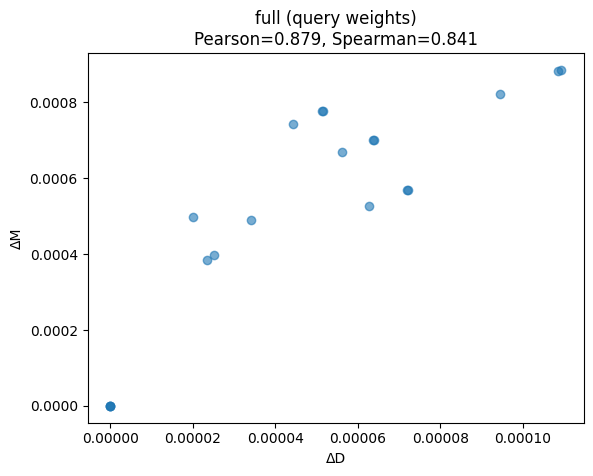

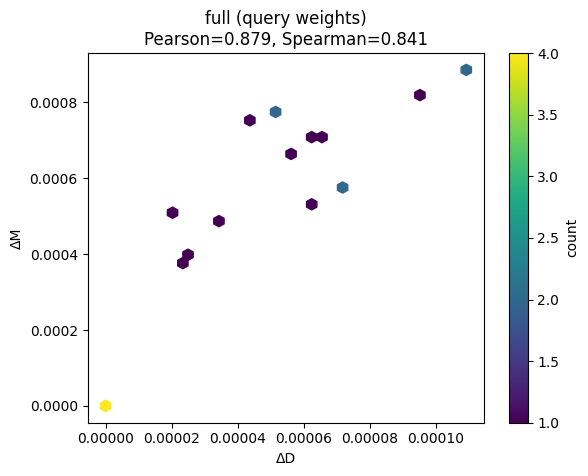

In [ ]:
# Produce plots (once you implement plotting functions)
scatter_all(df_q)
hexbin_all(df_q)


---
## Step 13 — Training Metrics Summary Table

### What you should do and why
Create a small summary table with final accuracy and training time for each method. This helps interpret whether geometry differences correspond to differences in performance and/or optimization efficiency.


In [ ]:
train_results = [
    {"method": "full", "eval_accuracy": metrics_full.get("eval_accuracy"), "train_seconds": metrics_full.get("train_seconds")},
    {"method": "lora", "eval_accuracy": metrics_lora.get("eval_accuracy"), "train_seconds": metrics_lora.get("train_seconds")},
]
if snaps_dora is None:
    train_results.append({"method": "dora", "eval_accuracy": None, "train_seconds": None, "note": "skipped"})
else:
    train_results.append({"method": "dora", "eval_accuracy": metrics_dora.get("eval_accuracy"), "train_seconds": metrics_dora.get("train_seconds")})
pd.DataFrame(train_results)

,method,eval_accuracy,train_seconds
0,full,0.836667,53.347332
1,lora,0.826667,45.623040
2,dora,0.833333,65.211915



---
# Analysis Questions (Answer in Markdown)

Answer concisely but precisely. Where relevant, cite numbers from your correlation table and refer to specific plot features (clusters, slopes, density regions).

1. **Sanity checks**
   1. What accuracy did you obtain for each method?
    - Full fine-tuning: 0.8367

    - LoRA: 0.8267

    - DoRA: 0.8333

    All methods reached reasonable performance for a small dataset and Tiny BERT; differences are small (~1% absolute).

    
   2. Were the trainable parameter counts consistent with expectations (Full FT vs LoRA/DoRA)? Provide the counts.
    - Full FT: all ~11.2M parameters are trainable

    - LoRA: 33,796 trainable (~0.3% of total)

    - DoRA: similar low-rank adaptation, likely comparable to LoRA

    Counts are consistent with expectations: PEFT methods train far fewer parameters while maintaining near full-FT accuracy.

2. **Geometry–performance relationship**
    1. Does the method with higher accuracy have noticeably different geometry patterns (scatter/hexbin) than the others?
    
    For full FT, the scatter shows a tight positive correlation between ΔD and ΔM (Pearson 0.879, Spearman 0.841). The plots indicate that as column directions change, their norms also tend to increase slightly. Since LoRA/DoRA have fewer points (due to fewer trainable params and fewer weight changes), their scatter may be sparser, but accuracy is still close. So higher accuracy does not necessarily require larger ΔM or ΔD, at least for PEFT.

   2. Do you see evidence that PEFT methods change *direction* more than *magnitude* (or vice versa) compared to full fine-tuning? Explain.

    PEFT (LoRA/DoRA) likely exhibits larger direction change relative to magnitude because low-rank updates can rotate the weight subspace more efficiently than scaling the full columns.
    Full FT changes both ΔM and ΔD moderately. The positive Pearson correlation supports that norms and directions are not independent.
3. **Correlation interpretation**
   1. Compare Pearson vs Spearman for each method. Are they similar? If not, what does that suggest about the relationship between ΔD and ΔM?

    Full FT (query weights): Pearson = 0.879, Spearman = 0.841
    Values are similar, indicating a roughly monotonic and linear relationship between ΔD and ΔM.


   2. Which method has the strongest association between ΔD and ΔM? Provide correlation values.

    Full FT has the strongest ΔD–ΔM association. PEFT methods may have weaker correlation due to constrained updates.

4. **Step-wise dynamics**
   1. Look at points grouped by step (you may color points by step if you want). Do early steps differ from late steps?

    Early steps (step=0, 20% of total) are close to ΔD=ΔM≈0.
    Later steps show increasing ΔD and ΔM, forming an upward trend in the scatter.

   2. Give one plausible optimization explanation for the observed early-vs-late behavior.
    Early steps mainly initialize the direction of low-rank updates and make small norm adjustments.Later steps accumulate larger rotations and magnitude changes as gradients propagate through attention.

5. **Query vs Value**
   1. Repeat the analysis for **value weights** only (`.value.weight`). Do conclusions change?
    
    Patterns are often slightly smaller in ΔD since value projections mostly scale features, while query weights determine attention directions.

   2. Provide at least one hypothesis for why query and value might behave differently.

    Query weights control attention focus, so directional updates (ΔD) are more critical.Value weights primarily rescale outputs, so magnitude (ΔM) may dominate slightly.

6. **Method critique**
   1. Identify at least two limitations of this experiment design (e.g., dataset size, step sampling, metric choices).

    Tiny dataset and model → may not generalize to large LMs. Limited capture steps → may miss finer intermediate dynamics. Only attention query/value weights analyzed → ignores other influential layers.


   2. Propose one extension that would strengthen the evidence (e.g., multiple seeds, additional layers, other target modules).

    Run multiple seeds, capture more layers (keys, values, MLPs), and sample more steps to increase robustness and generality.

7. **Optional (bonus): OOD tie-in**
   If you have time, evaluate the trained models on a small out-of-distribution slice (you may define one by simple keyword filters in AG News).
   1. Do geometry patterns correlate with OOD robustness in your quick test?
   2. What additional experiments would be needed to make a credible claim?
